
# Ejemplos de Regresión Logística con Explicaciones

Este notebook contiene dos ejemplos prácticos:
1. **Regresión logística binaria**: predicción de la supervivencia en el Titanic con un dataset ficticio.
2. **Regresión logística multinomial**: predicción de la preferencia de voto entre tres partidos políticos.

En cada ejemplo se explican las funciones, parámetros y pasos utilizados.



## Importación de librerías

- `pandas` y `numpy`: manejo de datos y operaciones matemáticas.
- `matplotlib.pyplot` y `seaborn`: visualización de datos.
- `sklearn.model_selection.train_test_split`: dividir los datos en entrenamiento y prueba.
- `sklearn.linear_model.LogisticRegression`: modelo de regresión logística.
- `sklearn.metrics`: métricas de evaluación (matriz de confusión, reporte de clasificación).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix



## Ejemplo 1: Regresión Logística Binaria (Titanic)

Este dataset ficticio contiene:
- **Edad**: valor numérico entre 1 y 80 años.
- **Clase**: clase del pasajero (Primera, Segunda, Tercera).
- **Pariente**: 1 si viajaba con un familiar, 0 si no.
- **Puente**: letra donde estaba su camarote.
- **Género**: Hombre o Mujer.
- **Sobrevivió**: variable objetivo binaria (1 = sí, 0 = no).

La regresión logística binaria se usa para predecir si un pasajero sobrevivió o no.


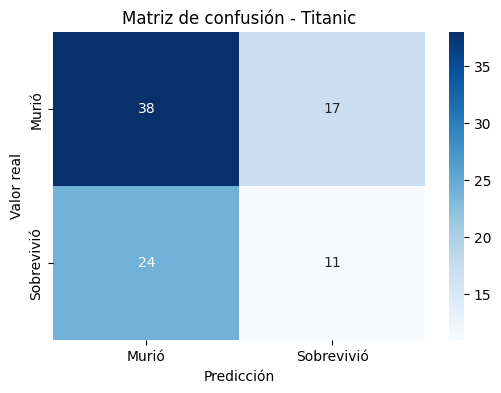

              precision    recall  f1-score   support

           0       0.61      0.69      0.65        55
           1       0.39      0.31      0.35        35

    accuracy                           0.54        90
   macro avg       0.50      0.50      0.50        90
weighted avg       0.53      0.54      0.53        90



In [ ]:
# Generamos un dataset ficticio del Titanic
np.random.seed(42)
n = 300
titanic_data = pd.DataFrame({
    "Edad": np.random.randint(1, 80, n),
    "Clase": np.random.choice(["Primera", "Segunda", "Tercera"], n),
    "Pariente": np.random.choice([0, 1], n),
    "Puente": np.random.choice(["A", "B", "C", "D", "E"], n),
    "Genero": np.random.choice(["Hombre", "Mujer"], n),
    "Sobrevivio": np.random.choice([0, 1], n, p=[0.6, 0.4])
})

# Convertimos variables categóricas en variables dummies (0/1)
titanic_encoded = pd.get_dummies(titanic_data, drop_first=True)

# Separamos las variables predictoras (X) y la variable objetivo (y)
X_titanic = titanic_encoded.drop("Sobrevivio", axis=1)
y_titanic = titanic_encoded["Sobrevivio"]

# Dividimos en datos de entrenamiento y prueba
# test_size=0.3 significa 30% para prueba, 70% para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X_titanic, y_titanic, test_size=0.3, random_state=42)

# Creamos el modelo de regresión logística binaria
# max_iter=1000 define el número máximo de iteraciones del algoritmo
log_reg_binaria = LogisticRegression(max_iter=1000)
log_reg_binaria.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred_titanic = log_reg_binaria.predict(X_test)

# Matriz de confusión para comparar valores reales vs predicciones
cm_titanic = confusion_matrix(y_test, y_pred_titanic)
plt.figure(figsize=(6,4))
sns.heatmap(cm_titanic, annot=True, fmt="d", cmap="Blues", xticklabels=["Murió", "Sobrevivió"], yticklabels=["Murió", "Sobrevivió"])
plt.title("Matriz de confusión - Titanic")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
plt.show()

# Reporte de métricas: precisión, recall y F1-score
print(classification_report(y_test, y_pred_titanic))


TP (True Positive): predijo “sí” y era “sí”
FP (False Positive): predijo “sí” pero era “no”
FN (False Negative): predijo “no” pero era “sí”
TN (True Negative): predijo “no” y era “no”

Precisión: De todo lo que el modelo dijo que era positivo… ¿cuánto acertó?

Precision= TP/(FP+TP)
	​
Interpretación
Alta precision → pocos falsos positivos
“Cuando el modelo dice que algo es positivo, suele tener razón”

Recall (Sensibilidad o exhaustividad)

Responde a: De todos los positivos reales… ¿cuántos detectó el modelo?

Recall= TP/(FP/TP)
	​
Interpretación
Alto recall → pocos falsos negativos
“Detecta casi todos los casos positivos”

F1-score

Combina precision y recall en una sola métrica:


Interpretación
Es la media armónica
Solo es alto si ambas (precision y recall) son altas

Precision → calidad de los positivos predichos
Recall → cantidad de positivos detectados
F1 → equilibrio entre ambos


## Ejemplo 2: Regresión Logística Multinomial (Votantes)

Este dataset ficticio contiene:
- **Edad**: número entre 18 y 80 años.
- **Género**: Hombre o Mujer.
- **Ingresos**: ingresos mensuales (500 a 5000).
- **Estudios**: Bajo, Medio o Alto.
- **Trabajo**: 1 si tiene trabajo, 0 si no.
- **Robo**: 1 si ha sufrido robo, 0 si no.
- **Partido**: variable objetivo categórica con 3 clases (A, B, C).

La regresión logística multinomial se usa cuando la variable a predecir tiene más de dos clases.


In [1]:
# Generamos un dataset ficticio de votantes
n = 400
votantes_data = pd.DataFrame({
    "Edad": np.random.randint(18, 80, n),
    "Genero": np.random.choice(["Hombre", "Mujer"], n),
    "Ingresos": np.random.randint(500, 5000, n),
    "Estudios": np.random.choice(["Bajo", "Medio", "Alto"], n),
    "Trabajo": np.random.choice([0, 1], n),
    "Robo": np.random.choice([0, 1], n),
    "Partido": np.random.choice(["A", "B", "C"], n)
})

# Separamos la variable objetivo antes de aplicar one-hot encoding
y_votantes = votantes_data["Partido"]
X_votantes = pd.get_dummies(votantes_data.drop("Partido", axis=1), drop_first=True)

# Dividimos en datos de entrenamiento y prueba
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_votantes, y_votantes, test_size=0.3, random_state=42)

# Modelo de regresión logística multinomial
# multi_class="multinomial" especifica que es un problema con más de dos clases
# solver="lbfgs" es el algoritmo de optimización recomendado
log_reg_multi = LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs")
log_reg_multi.fit(X_train_v, y_train_v)

# Predicciones
y_pred_votantes = log_reg_multi.predict(X_test_v)

# Matriz de confusión
cm_votantes = confusion_matrix(y_test_v, y_pred_votantes, labels=["A", "B", "C"])
plt.figure(figsize=(6,4))
sns.heatmap(cm_votantes, annot=True, fmt="d", cmap="Greens", xticklabels=["A", "B", "C"], yticklabels=["A", "B", "C"])
plt.title("Matriz de confusión - Votantes")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
plt.show()

# Reporte de métricas
print(classification_report(y_test_v, y_pred_votantes))


NameError: name 'pd' is not defined